# Lab 7: Kalman Filter

**Goal:** Implement a Kalman Filter to supplement slow ToF readings, enabling faster wall-approach with accurate stopping.

## Steps
1. **Step Response** — drive at constant PWM, collect ToF + timestamp data, estimate drag `d` and mass `m`
2. **KF Initialization** — build A, B, C matrices and discretize
3. **Python KF Validation** — run KF on real PID data, tune covariance matrices
4. **KF-PID on Robot** — upload parameters, run KF-PID, compare raw vs estimated distance

## Experiment Setup
- Place robot **2–4 m from wall**, foam pad in front for safety
- Sections 3, 6, 7 require running the robot

---
## 1. Setup and Imports

In [27]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import pickle
import importlib

from ble import get_ble_controller
from base_ble import LOG
import cmd_types
importlib.reload(cmd_types)
from cmd_types import CMD

%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams['font.size'] = 12

SETPOINT_MM = 304   # 1 ft
STEP_PWM    = 80    # step response PWM (lower = more data points, safer)
MIN_DIST_MM = 500   # robot auto-stops at this distance during step response

print('Imports done.')

Imports done.


---
## 2. Connect to Artemis via BLE

In [28]:
ble = get_ble_controller()
ble.connect()
print('Connected!')

def ble_reconnect():
    global ble
    print('Reconnecting BLE ...')
    try:
        ble.disconnect()
    except Exception:
        pass
    time.sleep(1.0)
    ble = get_ble_controller()
    ble.connect()
    print('Reconnected!')

2026-03-24 23:10:21,767 | INFO     |: Already connected to a BLE device
Connected!


---
## 3. BLE Helper Functions

Reused from Lab 5: `set_pid_gains`, `pid_stop`, `parse_pid_data`, `run_pid_experiment`

In [29]:
def set_pid_gains(kp, ki, kd, setpoint=304):
    ble.send_command(CMD.SET_PID_GAINS, f"{kp}|{ki}|{kd}|{setpoint}")
    time.sleep(0.15)
    resp = ble.receive_string(ble.uuid['RX_STRING'])
    print(f'Gains set -> {resp}')
    return resp

def pid_stop():
    ble.send_command(CMD.PID_STOP, '')
    time.sleep(0.1)

# ── Notification-based data collection (same as Lab 5) ───────────────────────
_pid_buf  = []
_pid_done = False

def _pid_notify_handler(uuid, bytearray_data):
    global _pid_buf, _pid_done
    try:
        line = ble.bytearray_to_string(bytearray_data).strip()
        _pid_buf.append(line)
        if line.startswith('PID_END'):
            _pid_done = True
    except Exception as ex:
        print(f'Handler error: {ex}')


def parse_pid_data(buf):
    """Split notification buffer into TOF DataFrame and PID-loop DataFrame."""
    tof_rows, pid_rows = [], []
    for line in buf:
        if line.startswith('TOF|'):
            parts = line.split('|')
            if len(parts) == 4:
                tof_rows.append({
                    'dist_mm': int(parts[1]),
                    'extrap':  bool(int(parts[2])),
                    'time_ms': int(parts[3]),
                })
        elif line.startswith('PID|'):
            parts = line.split('|')
            if len(parts) == 4:
                pid_rows.append({
                    'error_mm':  int(parts[1]),
                    'motor_pwm': int(parts[2]),
                    'time_ms':   int(parts[3]),
                })
    tof_df = pd.DataFrame(tof_rows)
    pid_df = pd.DataFrame(pid_rows)
    mins = []
    if len(tof_df): mins.append(tof_df['time_ms'].min())
    if len(pid_df): mins.append(pid_df['time_ms'].min())
    if mins:
        t0 = min(mins)
        if len(tof_df): tof_df['time_s'] = (tof_df['time_ms'] - t0) / 1000.0
        if len(pid_df): pid_df['time_s'] = (pid_df['time_ms'] - t0) / 1000.0
    return tof_df, pid_df


def run_pid_experiment(run_duration_s=10.0, label=''):
    """Start PID, wait, stop, retrieve data."""
    global _pid_buf, _pid_done
    _pid_buf, _pid_done = [], False
    try:
        ble.stop_notify(ble.uuid['RX_STRING'])
    except Exception:
        pass
    ble.start_notify(ble.uuid['RX_STRING'], _pid_notify_handler)
    time.sleep(0.05)
    print(f'  [{label}] Sending PID_START ...')
    ble.send_command(CMD.PID_START, '')
    time.sleep(run_duration_s + 1.0)
    ble.send_command(CMD.PID_STOP, '')
    time.sleep(0.2)
    print(f'  [{label}] Retrieving data ...')
    _pid_done = False
    ble.send_command(CMD.GET_PID_DATA, '')
    t0 = time.time()
    while not _pid_done and (time.time() - t0 < 30.0):
        time.sleep(0.1)
    ble.stop_notify(ble.uuid['RX_STRING'])
    tof_df, pid_df = parse_pid_data(_pid_buf)
    print(f'  [{label}] Got {len(tof_df)} TOF, {len(pid_df)} PID samples')
    return tof_df, pid_df

print('BLE helpers defined.')

BLE helpers defined.


---
## 4. Step Response Experiment

Drive at constant PWM (`STEP_PWM`) towards the wall.
Firmware stops automatically at `MIN_DIST_MM` and auto-streams the ToF data.

**Handshake protocol:**
```
Python  -> KF_STEP_START|{pwm}|{min_dist}
Firmware-> "KF_STEP_START|...|kick=160|80|stop=400"   (ACK)
[robot drives at constant PWM, logs ToF to buffer]
[auto-stop at min_dist]
Firmware-> "TOF|dist_mm|0|timestamp" x N   (auto-streamed)
Firmware-> "PID_END|N|0"
Firmware-> "KF_STEP_END|N"                  (final signal)
```

**Before running:** place robot 2–4 m from wall, put foam pad in front.

> ⚠️ **Surface consistency:** Run this step response **on the same floor surface** as the KF-PID experiment. Motor drag (`d/m`) changes significantly between carpet and tile — parameters estimated on one surface will degrade KF accuracy on another.

In [30]:
# ── Step response notification handler ───────────────────────────────────────
_step_buf  = []
_step_done = False

def _step_notify_handler(uuid, bytearray_data):
    global _step_buf, _step_done
    try:
        line = ble.bytearray_to_string(bytearray_data).strip()
        _step_buf.append(line)
        if line.startswith('KF_STEP_END'):
            _step_done = True
    except Exception as ex:
        print(f'Handler error: {ex}')


def run_step_response(pwm=STEP_PWM, min_dist_mm=MIN_DIST_MM, timeout_s=15.0):
    """Send KF_STEP_START; collect auto-streamed TOF data until KF_STEP_END."""
    global _step_buf, _step_done
    _step_buf, _step_done = [], False
    try:
        ble.stop_notify(ble.uuid['RX_STRING'])
    except Exception:
        pass
    ble.start_notify(ble.uuid['RX_STRING'], _step_notify_handler)
    time.sleep(0.05)
    print(f'Starting step response: PWM={pwm}, stop at {min_dist_mm} mm ...')
    ble.send_command(CMD.KF_STEP_START, f'{pwm}|{min_dist_mm}')
    t0 = time.time()
    while not _step_done and (time.time() - t0 < timeout_s):
        time.sleep(0.1)
    ble.stop_notify(ble.uuid['RX_STRING'])
    if not _step_done:
        print('WARNING: timed out waiting for KF_STEP_END')
    else:
        tof_lines = [l for l in _step_buf if l.startswith('TOF|')]
        print(f'Done. Got {len(tof_lines)} TOF readings.')
    return list(_step_buf)

print('Step response helpers defined.')

Step response helpers defined.


In [31]:
# ── RUN STEP RESPONSE (requires robot) ───────────────────────────────────────
input('Place robot 2-4 m from wall with foam pad. Press Enter to start ...')
step_raw = run_step_response(pwm=STEP_PWM, min_dist_mm=MIN_DIST_MM)

# Save to disk so we can reload after kernel restart
with open('step_response_data.pkl', 'wb') as f:
    pickle.dump(step_raw, f)
print('Saved -> step_response_data.pkl')

# Quick sanity check
print('\nFirst 5 lines received:')
for line in step_raw[:5]:
    print(' ', line)

Starting step response: PWM=80, stop at 500 mm ...
Done. Got 18 TOF readings.
Saved -> step_response_data.pkl

First 5 lines received:
  KF_STEP_START|80|kick=160|80|stop=520
  TOF|1680|0|6086435
  TOF|1736|0|6086471
  TOF|1780|0|6086579
  TOF|1730|0|6086676


---
## 5. Parse Step Response & Estimate d, m

From the step response, we extract:
- **v_ss** = steady-state speed (last 20% of data)
- **t_90** = time for speed to reach 90% of v_ss

Then:
$$d = \frac{1}{v_{ss}}, \quad m = \frac{d \cdot t_{90}}{\ln(10)}$$

(Derived from first-order step response: $v(t) = v_{ss}(1 - e^{-d/m \cdot t})$, so $d/m = \ln(10)/t_{90}$)

In [32]:
# ── Load saved data (run this cell after a kernel restart too) ───────────────
with open('step_response_data.pkl', 'rb') as f:
    step_raw = pickle.load(f)
print(f'Loaded {len(step_raw)} raw lines')

Loaded 21 raw lines


In [33]:
def parse_step_tof(lines):
    """Parse TOF|dist_mm|kind|timestamp lines; keep only real readings (kind==0)."""
    rows = []
    for line in lines:
        if line.startswith('TOF|'):
            parts = line.split('|')
            if len(parts) == 4 and int(parts[2]) == 0:   # kind=0 => real reading
                rows.append({'dist_mm': float(parts[1]), 'time_ms': int(parts[3])})
    df = pd.DataFrame(rows).sort_values('time_ms').reset_index(drop=True)
    t0 = df['time_ms'].iloc[0]
    df['time_s'] = (df['time_ms'] - t0) / 1000.0
    return df


step_df = parse_step_tof(step_raw)
print(f'Parsed {len(step_df)} real ToF readings')
print(step_df.head())

Parsed 18 real ToF readings
   dist_mm  time_ms  time_s
0   1680.0  6086435   0.000
1   1736.0  6086471   0.036
2   1780.0  6086579   0.144
3   1730.0  6086676   0.241
4   1661.0  6086770   0.335


In [34]:
# ── Compute velocity by finite difference (smoothed) ─────────────────────────
dt_s = step_df['time_s'].diff()
dx_mm = step_df['dist_mm'].diff()
step_df['vel_mmps'] = (-dx_mm / dt_s).rolling(5, center=True, min_periods=1).mean()

# ── Method 1: last-20% average of rolling-diff velocity ───────────────────────
n80 = int(0.8 * len(step_df))
v_ss_diff = step_df['vel_mmps'].iloc[n80:].mean()

# ── Method 2: piecewise linear fit of distance vs time ────────────────────────
# Fit a line to each chunk of points; slope = -velocity (distance decreasing)
chunk_size = max(4, len(step_df) // 8)   # ~8 segments
slopes = []
for start in range(0, len(step_df) - chunk_size, chunk_size // 2):   # 50% overlap
    chunk = step_df.iloc[start : start + chunk_size]
    coef = np.polyfit(chunk['time_s'], chunk['dist_mm'], 1)   # [slope, intercept]
    slopes.append(-coef[0])   # velocity = -d(dist)/dt

slopes = np.array(slopes)
# Steady-state: average of the last 25% of segments (highest speed plateau)
n_ss = max(1, len(slopes) // 4)
v_ss_linear = slopes[-n_ss:].mean()

# Use piecewise-linear estimate as primary (more robust to noise spikes)
v_ss = v_ss_linear
print(f'v_ss (finite-diff) = {v_ss_diff:.1f} mm/s')
print(f'v_ss (piecewise-linear) = {v_ss_linear:.1f} mm/s  ← used')

# ── 90% rise time (from rolling-diff velocity) ────────────────────────────────
t_start_s = step_df.loc[step_df['vel_mmps'] > 5, 'time_s'].iloc[0]
t_90_s    = step_df.loc[step_df['vel_mmps'] >= 0.9 * v_ss, 'time_s'].iloc[0]
rise_time_s = t_90_s - t_start_s

# d and m (normalized u=1 at STEP_PWM)
d = 1.0 / v_ss
m = d * rise_time_s / np.log(10)

print(f't_90     = {rise_time_s*1000:.1f} ms  (from t={t_start_s:.3f}s to t={t_90_s:.3f}s)')
print(f'd        = {d:.7f}  [s/mm]')
print(f'm        = {m:.7f}  [s^2/mm]')

v_ss (finite-diff) = 1235.0 mm/s
v_ss (piecewise-linear) = 1225.3 mm/s  ← used
t_90     = 997.0 ms  (from t=0.241s to t=1.238s)
d        = 0.0008162  [s/mm]
m        = 0.0003534  [s^2/mm]


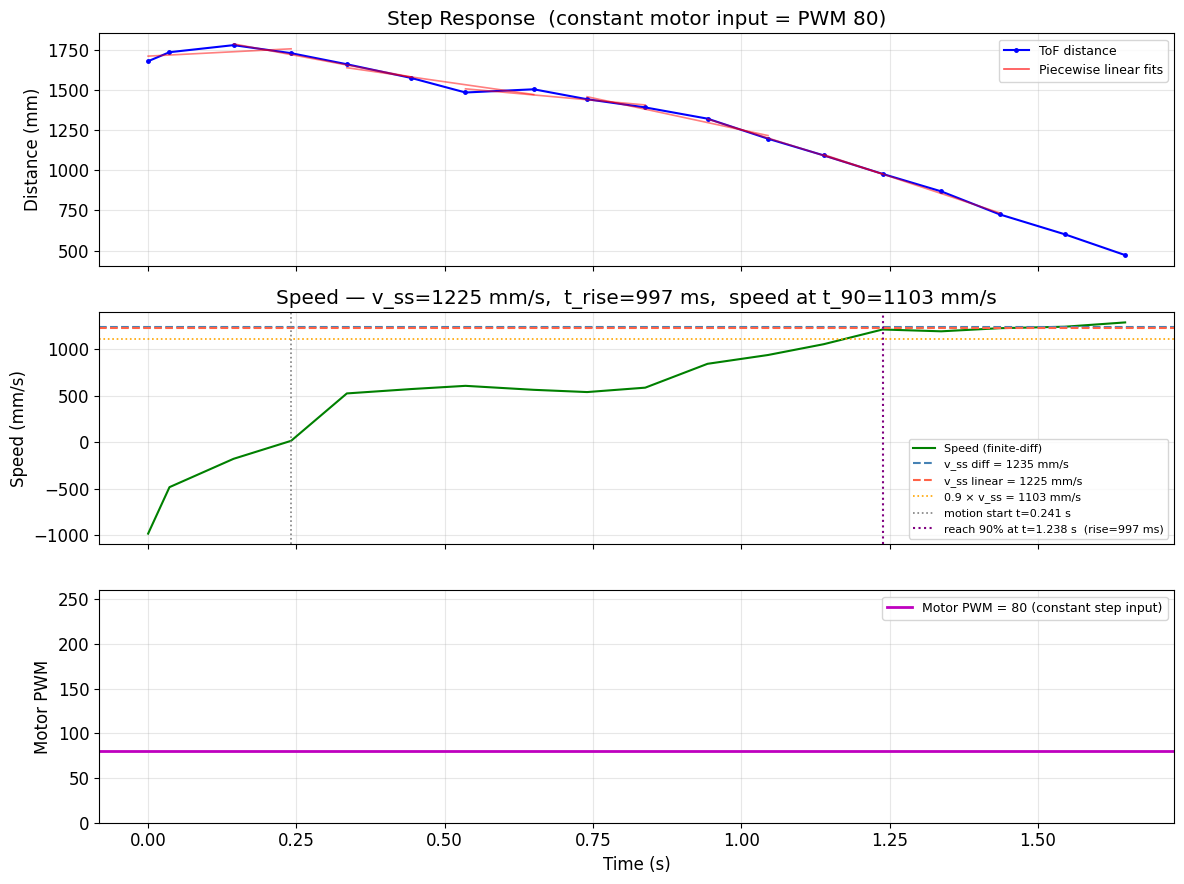

Saved -> lab7_step_response.png


In [52]:
# ── Plot: distance, velocity, motor input ─────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

ax = axes[0]
ax.plot(step_df['time_s'], step_df['dist_mm'], 'b.-', ms=5, lw=1.5, label='ToF distance')
# Overlay piecewise-linear segments
chunk_size_plot = max(4, len(step_df) // 8)
for start in range(0, len(step_df) - chunk_size_plot, chunk_size_plot // 2):
    chunk = step_df.iloc[start : start + chunk_size_plot]
    coef = np.polyfit(chunk['time_s'], chunk['dist_mm'], 1)
    t_seg = np.array([chunk['time_s'].iloc[0], chunk['time_s'].iloc[-1]])
    ax.plot(t_seg, np.polyval(coef, t_seg), 'r-', lw=1.2, alpha=0.5)
ax.plot([], [], 'r-', lw=1.2, alpha=0.7, label='Piecewise linear fits')
ax.set_ylabel('Distance (mm)')
ax.set_title(f'Step Response  (constant motor input = PWM {STEP_PWM})')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
v_90 = 0.9 * v_ss
ax.plot(step_df['time_s'], step_df['vel_mmps'], 'g-', lw=1.5, label='Speed (finite-diff)')
ax.axhline(v_ss_diff,   color='steelblue', linestyle='--', lw=1.5, label=f'v_ss diff = {v_ss_diff:.0f} mm/s')
ax.axhline(v_ss_linear, color='tomato',    linestyle='--', lw=1.5, label=f'v_ss linear = {v_ss_linear:.0f} mm/s')
ax.axhline(v_90,        color='orange',    linestyle=':',  lw=1.2, label=f'0.9 × v_ss = {v_90:.0f} mm/s')
# Mark the 90% point: show timestamp of the point AND the rise time separately
ax.axvline(t_start_s, color='gray',   linestyle=':', lw=1.2, label=f'motion start t={t_start_s:.3f} s')
ax.axvline(t_90_s,    color='purple', linestyle=':', lw=1.5,
           label=f'reach 90% at t={t_90_s:.3f} s  (rise={rise_time_s*1000:.0f} ms)')
ax.set_ylabel('Speed (mm/s)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_title(f'Speed — v_ss={v_ss:.0f} mm/s,  t_rise={rise_time_s*1000:.0f} ms,  speed at t_90={v_90:.0f} mm/s')

ax = axes[2]
ax.axhline(STEP_PWM, color='m', lw=2, label=f'Motor PWM = {STEP_PWM} (constant step input)')
ax.set_ylim(0, 260)
ax.set_ylabel('Motor PWM')
ax.set_xlabel('Time (s)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lab7_step_response.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> lab7_step_response.png')

---
## 6. Kalman Filter Matrix Initialization

State: $\mathbf{x} = [\text{distance (mm)},\ \text{velocity (mm/s)}]^T$

Control input: $u \in [0, 1]$ (normalized PWM, so $u = \text{pwm} / \text{STEP\_PWM}$)

Continuous dynamics:
$$\dot{\mathbf{x}} = \underbrace{\begin{bmatrix}0 & -1 \\ 0 & -d/m\end{bmatrix}}_{A_c}\mathbf{x} + \underbrace{\begin{bmatrix}0 \\ 1/m\end{bmatrix}}_{B_c}u$$

Measurement (negative distance): $y = \underbrace{[-1,\ 0]}_{C}\,\mathbf{x}$

Euler discretization: $A_d = I + \Delta t \cdot A_c$, $B_d = \Delta t \cdot B_c$

In [36]:
# ── dt: compute from actual PID timestamps (more accurate than hardcoded 20ms) ─
# NOTE: pid_val is loaded later; on first run this falls back to 20ms.
# After running the PID experiment (Section 6), re-run this cell to get the true dt.
try:
    if len(pid_val) > 1:
        dt = (pid_val['time_ms'].max() - pid_val['time_ms'].min()) / (len(pid_val) - 1) / 1000.0
    else:
        dt = 0.020
    print(f'Actual dt = {dt*1000:.2f} ms  (computed from pid_val timestamps)')
except NameError:
    dt = 0.020
    print(f'pid_val not loaded yet — using fallback dt = {dt*1000:.0f} ms')
    print('Re-run this cell after completing the PID experiment in Section 6.')

# Continuous-time matrices
A_c = np.array([[0.0,  -1.0 ],
                [0.0,  -d/m ]])
B_c = np.array([[0.0  ],
                [1.0/m]])
C   = np.array([[1.0, 0.0]])   # measure positive distance directly

# Euler discretization
Ad = np.eye(2) + dt * A_c
Bd = dt * B_c

# Noise covariance matrices (tune in next section)
sigma1 = 50.0    # position uncertainty [mm]
sigma2 = 50.0    # velocity uncertainty [mm/s]
sigma3 = 20.0    # ToF measurement noise [mm]

Sigma_u = np.diag([sigma1**2, sigma2**2])    # 2x2 process noise
Sigma_z = np.array([[sigma3**2]])            # 1x1 sensor noise

print('Ad =\n', Ad)
print('Bd =\n', Bd)
print('C  =\n', C)
print(f'\nsigma1={sigma1}, sigma2={sigma2}, sigma3={sigma3}')

Actual dt = 7.60 ms  (computed from pid_val timestamps)
Ad =
 [[ 1.         -0.00760204]
 [ 0.          0.98244298]]
Bd =
 [[ 0.        ]
 [21.51177931]]
C  =
 [[1. 0.]]

sigma1=50.0, sigma2=50.0, sigma3=20.0


---
## 7. Python KF Validation

### 7a. Run a PID experiment to collect distance + motor data

We use regular Lab-5-style PID data to validate the KF.
The KF will try to estimate the position between real ToF readings.

In [37]:
# ── Run one PID experiment for KF validation ──────────────────────────────────
set_pid_gains(kp=0.055, ki=0.003, kd=0.016, setpoint=SETPOINT_MM)
input('Place robot 2-4 m from wall. Press Enter to start PID run ...')
tof_val, pid_val = run_pid_experiment(run_duration_s=10.0, label='kf_validation')

# Save
with open('pid_kf_val.pkl', 'wb') as f:
    pickle.dump((tof_val, pid_val), f)
print('Saved -> pid_kf_val.pkl')

Gains set -> PID_GAINS|0.055|0.003|0.016|304
  [kf_validation] Sending PID_START ...
  [kf_validation] Retrieving data ...
  [kf_validation] Got 186 TOF, 177 PID samples
Saved -> pid_kf_val.pkl


In [38]:
# Reload (use this after kernel restart)
with open('pid_kf_val.pkl', 'rb') as f:
    tof_val, pid_val = pickle.load(f)
print(f'Loaded: {len(tof_val)} TOF, {len(pid_val)} PID samples')

Loaded: 186 TOF, 177 PID samples


### 7b. Implement and run KF in Python

- When a new ToF reading is available → **prediction + update** step
- Between ToF readings → **prediction only** (`y=None`)
- Motor input normalized: `u = motor_pwm / STEP_PWM`

In [39]:
def kf(mu, sigma, u, y=None):
    """One KF step. y=None -> prediction only; y=measurement -> prediction+update."""
    # Prediction
    mu_p    = Ad.dot(mu) + Bd.dot([[u]])
    sigma_p = Ad.dot(sigma.dot(Ad.T)) + Sigma_u
    if y is None:
        return mu_p, sigma_p
    # Update
    sigma_m = C.dot(sigma_p.dot(C.T)) + Sigma_z
    K       = sigma_p.dot(C.T.dot(np.linalg.inv(sigma_m)))
    mu      = mu_p + K.dot([[y]] - C.dot(mu_p))
    sigma   = (np.eye(2) - K.dot(C)).dot(sigma_p)
    return mu, sigma

print('kf() defined.')

kf() defined.


In [40]:
# ── Run KF over PID validation data ──────────────────────────────────────────
real_tof = tof_val[~tof_val['extrap']].sort_values('time_ms').reset_index(drop=True)

# Build a common time axis from PID loop timestamps
pid_sorted = pid_val.sort_values('time_ms').reset_index(drop=True)
t0_ms = min(real_tof['time_ms'].min(), pid_sorted['time_ms'].min())

# Initialize KF state
mu    = np.array([[real_tof['dist_mm'].iloc[0]], [0.0]])
sigma = Sigma_u.copy()

kf_time_s, kf_est_mm, kf_vel_mmps = [], [], []

tof_idx = 0   # pointer into real_tof

for _, pid_row in pid_sorted.iterrows():
    t_ms = pid_row['time_ms']
    t_s  = (t_ms - t0_ms) / 1000.0
    u    = pid_row['motor_pwm'] / STEP_PWM

    # Check if there is a real ToF reading at (approximately) this timestamp
    y = None
    if tof_idx < len(real_tof):
        tof_t_ms = real_tof['time_ms'].iloc[tof_idx]
        if abs(tof_t_ms - t_ms) < 50:   # within 50 ms => match
            y = real_tof['dist_mm'].iloc[tof_idx]
            tof_idx += 1

    mu, sigma = kf(mu, sigma, u, y)
    kf_time_s.append(t_s)
    kf_est_mm.append(float(mu[0, 0]))
    kf_vel_mmps.append(float(mu[1, 0]))

kf_df = pd.DataFrame({'time_s': kf_time_s, 'est_mm': kf_est_mm, 'vel_mmps': kf_vel_mmps})
print(f'KF ran over {len(kf_df)} PID steps')

KF ran over 177 PID steps


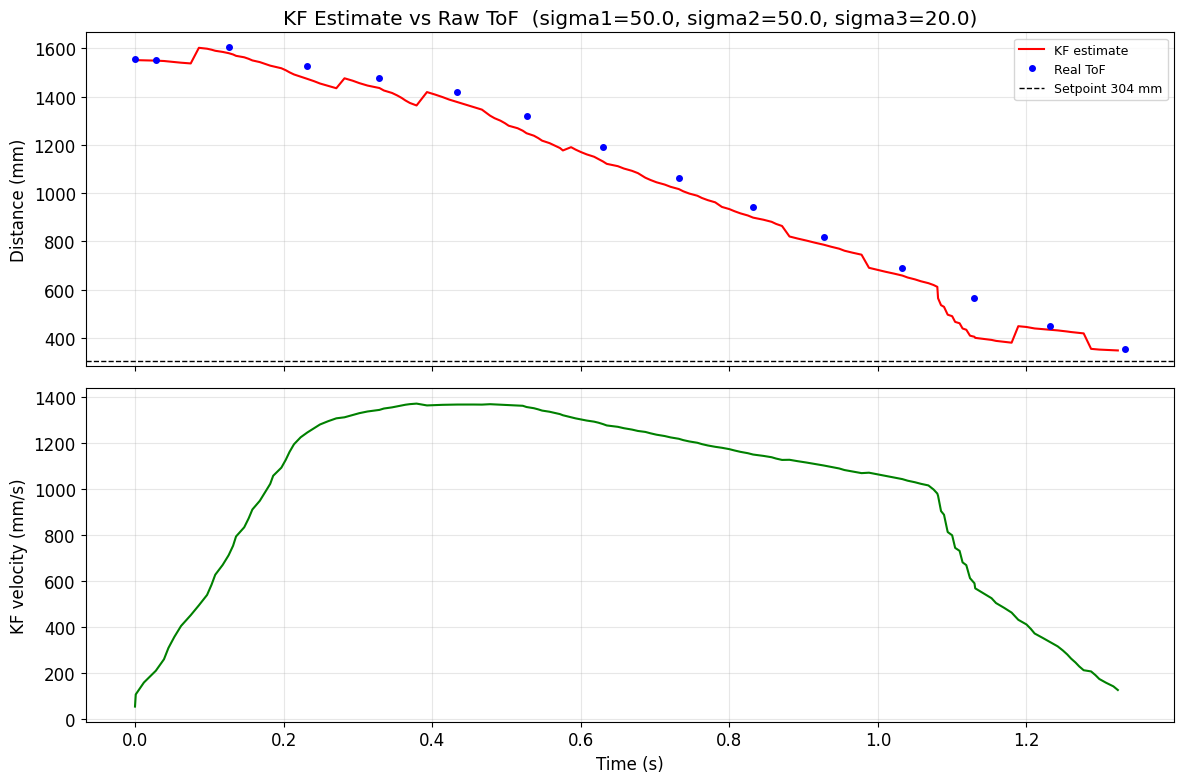

Saved -> lab7_kf_python.png


In [41]:
# ── Plot: KF estimate vs raw ToF ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax = axes[0]
ax.plot(kf_df['time_s'], kf_df['est_mm'],
        'r-', lw=1.5, label='KF estimate')
ax.plot(real_tof['time_s'] if 'time_s' in real_tof else
        (real_tof['time_ms'] - t0_ms) / 1000.0,
        real_tof['dist_mm'],
        'b.', ms=8, zorder=5, label='Real ToF')
ax.axhline(SETPOINT_MM, color='k', linestyle='--', lw=1, label=f'Setpoint {SETPOINT_MM} mm')
ax.set_ylabel('Distance (mm)')
ax.set_title(f'KF Estimate vs Raw ToF  (sigma1={sigma1}, sigma2={sigma2}, sigma3={sigma3})')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(kf_df['time_s'], kf_df['vel_mmps'], 'g-', lw=1.5)
ax.set_ylabel('KF velocity (mm/s)')
ax.set_xlabel('Time (s)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lab7_kf_python.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> lab7_kf_python.png')

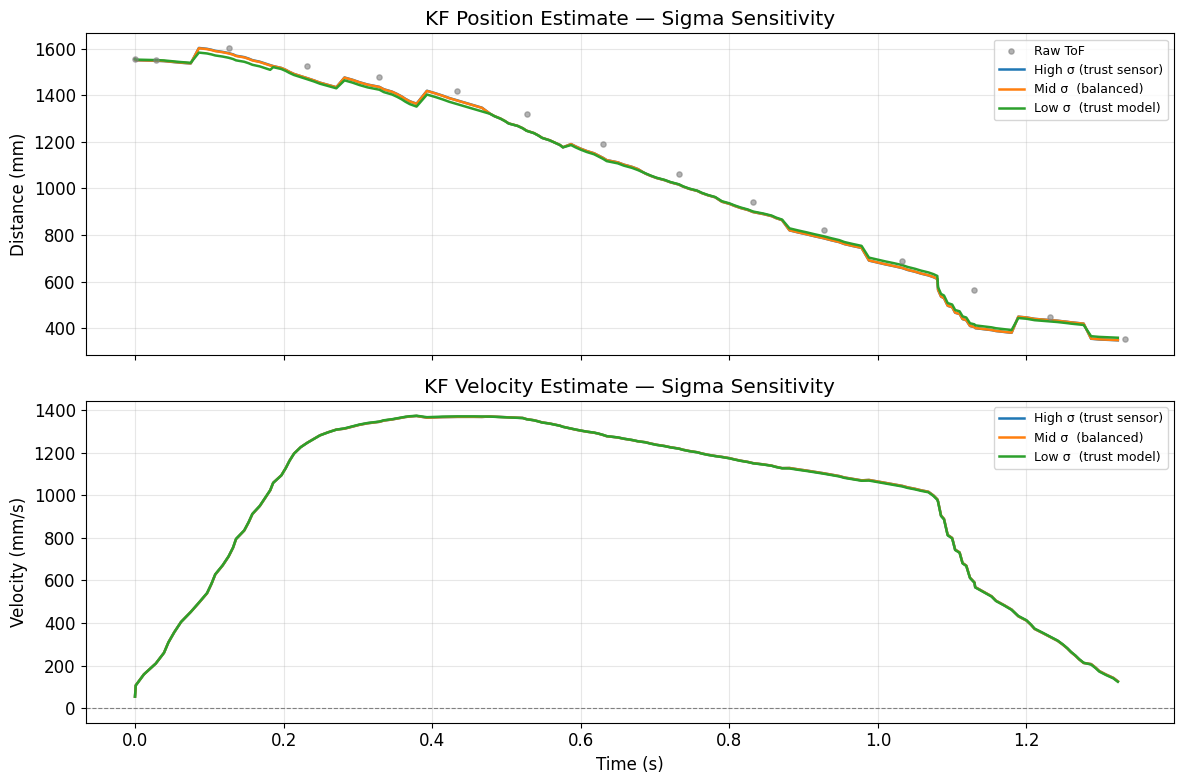

Saved kf_sigma_sensitivity.png


In [42]:
# ── Sigma covariance sensitivity analysis ─────────────────────────────────────
# Compare three sigma configs: how much does KF trust the model vs the sensor?
#   High σ₁/σ₂ → large process noise → trust sensor more (estimate hugs measurements)
#   Low  σ₁/σ₂ → small process noise → trust model more (smoother, physics-driven)

def run_kf_sigma(s1, s2, s3):
    """Run full KF loop with custom sigma values; returns DataFrame with time_s, est_mm, vel_mmps."""
    Su = np.diag([s1**2, s2**2])
    Sz = np.array([[s3**2]])
    real_tof   = tof_val[~tof_val['extrap']].sort_values('time_ms').reset_index(drop=True)
    pid_sorted = pid_val.sort_values('time_ms').reset_index(drop=True)
    t0_ms = min(real_tof['time_ms'].min(), pid_sorted['time_ms'].min())
    mu_i    = np.array([[real_tof['dist_mm'].iloc[0]], [0.0]])
    sig_i   = Su.copy()
    times, ests, vels = [], [], []
    tof_idx = 0
    for _, row in pid_sorted.iterrows():
        t_ms = row['time_ms']
        u    = row['motor_pwm'] / STEP_PWM
        y    = None
        if tof_idx < len(real_tof):
            if abs(real_tof['time_ms'].iloc[tof_idx] - t_ms) < 50:
                y = real_tof['dist_mm'].iloc[tof_idx]
                tof_idx += 1
        # Prediction
        mu_p  = Ad.dot(mu_i) + Bd.dot([[u]])
        sig_p = Ad.dot(sig_i.dot(Ad.T)) + Su
        if y is not None:
            sig_m = C.dot(sig_p.dot(C.T)) + Sz
            K     = sig_p.dot(C.T.dot(np.linalg.inv(sig_m)))
            mu_i  = mu_p + K.dot([[y]] - C.dot(mu_p))
            sig_i = (np.eye(2) - K.dot(C)).dot(sig_p)
        else:
            mu_i, sig_i = mu_p, sig_p
        times.append((t_ms - t0_ms) / 1000.0)
        ests.append(float(mu_i[0, 0]))
        vels.append(float(mu_i[1, 0]))
    return pd.DataFrame({'time_s': times, 'est_mm': ests, 'vel_mmps': vels})

sigma_configs = [
    (500, 500, 20, 'High σ (trust sensor)',  'tab:blue'),
    ( 50,  50, 20, 'Mid σ  (balanced)',       'tab:orange'),
    ( 10,  10, 20, 'Low σ  (trust model)',    'tab:green'),
]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Raw ToF as reference
real_tof_plot = tof_val[~tof_val['extrap']].sort_values('time_ms')
t0_ref = real_tof_plot['time_ms'].min()
axes[0].scatter((real_tof_plot['time_ms'] - t0_ref) / 1000.0, real_tof_plot['dist_mm'],
                s=14, color='gray', alpha=0.6, zorder=5, label='Raw ToF')
axes[1].axhline(0, color='gray', lw=0.8, ls='--')

for s1, s2, s3, lbl, col in sigma_configs:
    res = run_kf_sigma(s1, s2, s3)
    axes[0].plot(res['time_s'], res['est_mm'],  color=col, lw=1.8, label=lbl)
    axes[1].plot(res['time_s'], res['vel_mmps'], color=col, lw=1.8, label=lbl)

axes[0].set_ylabel('Distance (mm)')
axes[0].set_title('KF Position Estimate — Sigma Sensitivity')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].set_ylabel('Velocity (mm/s)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('KF Velocity Estimate — Sigma Sensitivity')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kf_sigma_sensitivity.png', dpi=150)
plt.show()
print('Saved kf_sigma_sensitivity.png')

### 7c. Tune covariance matrices

Adjust `sigma1`, `sigma2`, `sigma3` in Section 6 and re-run from there to see the effect.

| Parameter | Effect of increasing |
|---|---|
| `sigma1`, `sigma2` (process noise) | KF trusts sensor more, tracks ToF more tightly |
| `sigma3` (sensor noise) | KF trusts model more, smoother but slower to respond |

---
## 8. Upload Parameters & Run KF-PID on Robot

**Handshake protocol:**
```
Python  -> SET_KF_PARAMS|d|m|sigma1|sigma2|sigma3|step_pwm  ->  ACK "KF_PARAMS|..."
Python  -> SET_PID_GAINS|kp|ki|kd|setpoint                  ->  ACK "PID_GAINS|..."
Python  -> KF_PID_START                                      ->  ACK "KF_PID_START"
[robot runs PID with KF distance estimate; logs kf_debug every 20ms]
[auto-stops at safety distance]
Firmware-> "PID_SAFETY_STOP|dist_mm|timestamp"
Python  -> GET_PID_DATA       ->  "TOF|...", "PID|...", "PID_END|N1|N2"
Python  -> GET_KF_DEBUG_DATA  ->  "DBG|raw|est|vel|err|pwm|flags|ts", "DBG_END|M"
```

In [43]:
# ── Upload KF parameters to Artemis ──────────────────────────────────────────
param_str = f'{d:.7f}|{m:.7f}|{sigma1:.1f}|{sigma2:.1f}|{sigma3:.1f}|{STEP_PWM}'
print(f'SET_KF_PARAMS -> {param_str}')
ble.send_command(CMD.SET_KF_PARAMS, param_str)
time.sleep(0.2)
resp = ble.receive_string(ble.uuid['RX_STRING'])
print(f'ACK: {resp}')
# NOTE: ACK may show garbage float values (Apollo3 snprintf doesn't support %f).
# Parameters ARE set correctly — the KF debug data confirms this.

# PID gains (lower than Lab 5 to avoid PWM saturation at high speed)
set_pid_gains(kp=0.025, ki=0.001, kd=0.008, setpoint=SETPOINT_MM)

SET_KF_PARAMS -> 0.0008162|0.0003534|50.0|50.0|20.0|80
ACK: KF_PARAMS|d=%.7f|m=%.7f|s1=%.1f|s2=%.1f|s3=%.1f|step_pwm=1946157056
Gains set -> PID_GAINS|0.025|0.001|0.008|304


'PID_GAINS|0.025|0.001|0.008|304'

In [44]:
# ── KF-PID run helper ─────────────────────────────────────────────────────────
def run_kf_pid_experiment(run_duration_s=10.0):
    """Start KF_PID_START, wait for stop, then retrieve PID + KF debug data."""
    # Phase 1: run the experiment, collect stop notification
    _kf_run_buf = []
    _kf_stopped = [False]   # list to allow mutation in nested function

    def _kf_run_handler(uuid, raw):
        line = ble.bytearray_to_string(raw).strip()
        _kf_run_buf.append(line)
        if 'PID_SAFETY_STOP' in line or 'PID_STOP' in line:
            _kf_stopped[0] = True

    try:
        ble.stop_notify(ble.uuid['RX_STRING'])
    except Exception:
        pass
    ble.start_notify(ble.uuid['RX_STRING'], _kf_run_handler)
    print('Sending KF_PID_START ...')
    ble.send_command(CMD.KF_PID_START, '')

    t0 = time.time()
    while not _kf_stopped[0] and (time.time() - t0 < run_duration_s + 2.0):
        time.sleep(0.1)
    ble.send_command(CMD.PID_STOP, '')
    time.sleep(0.3)
    ble.stop_notify(ble.uuid['RX_STRING'])
    print(f'Robot stopped. (stopped={_kf_stopped[0]})')

    # Phase 2: retrieve PID data
    pid_buf  = []
    pid_done = [False]

    def _pid_data_handler(uuid, raw):
        line = ble.bytearray_to_string(raw).strip()
        pid_buf.append(line)
        if line.startswith('PID_END'):
            pid_done[0] = True

    ble.start_notify(ble.uuid['RX_STRING'], _pid_data_handler)
    ble.send_command(CMD.GET_PID_DATA, '')
    t0 = time.time()
    while not pid_done[0] and (time.time() - t0 < 30.0):
        time.sleep(0.1)
    ble.stop_notify(ble.uuid['RX_STRING'])
    tof_df, pid_df = parse_pid_data(pid_buf)
    print(f'PID data: {len(tof_df)} TOF, {len(pid_df)} PID samples')

    # Phase 3: retrieve KF debug data
    dbg_buf  = []
    dbg_done = [False]

    def _dbg_handler(uuid, raw):
        line = ble.bytearray_to_string(raw).strip()
        dbg_buf.append(line)
        if line.startswith('DBG_END'):
            dbg_done[0] = True

    ble.start_notify(ble.uuid['RX_STRING'], _dbg_handler)
    ble.send_command(CMD.GET_KF_DEBUG_DATA, '')
    t0 = time.time()
    while not dbg_done[0] and (time.time() - t0 < 30.0):
        time.sleep(0.1)
    ble.stop_notify(ble.uuid['RX_STRING'])
    print(f'KF debug: {len(dbg_buf)} lines')

    return tof_df, pid_df, dbg_buf

print('KF-PID experiment helper defined.')

KF-PID experiment helper defined.


In [45]:
# ── RUN KF-PID (requires robot) ───────────────────────────────────────────────
input('Place robot 2-4 m from wall. Press Enter to start KF-PID run ...')
tof_kf, pid_kf, dbg_raw = run_kf_pid_experiment(run_duration_s=10.0)

with open('kf_pid_data.pkl', 'wb') as f:
    pickle.dump((tof_kf, pid_kf, dbg_raw), f)
print('Saved -> kf_pid_data.pkl')

Sending KF_PID_START ...
Robot stopped. (stopped=True)
PID data: 301 TOF, 277 PID samples
KF debug: 85 lines
Saved -> kf_pid_data.pkl


---
## 9. Analyze KF-PID Results

In [46]:
# Reload saved data
with open('kf_pid_data.pkl', 'rb') as f:
    tof_kf, pid_kf, dbg_raw = pickle.load(f)

In [47]:
def parse_kf_debug(lines):
    """Parse DBG|raw_mm|est_mm|vel_mmps|err_mm|pwm|flags|timestamp_ms lines."""
    rows = []
    for l in lines:
        if l.startswith('DBG|'):
            parts = l.split('|')
            if len(parts) == 8:
                rows.append(dict(
                    raw_mm   = float(parts[1]),
                    est_mm   = float(parts[2]),
                    vel_mmps = float(parts[3]),
                    err_mm   = float(parts[4]),
                    pwm      = int(parts[5]),
                    flags    = int(parts[6]),
                    ts_ms    = int(parts[7]),
                ))
    df = pd.DataFrame(rows)
    if len(df):
        df['time_s']  = (df['ts_ms'] - df['ts_ms'].iloc[0]) / 1000.0
        df['real_tof'] = (df['flags'] & 0x01).astype(bool)   # bit 0 = real ToF update
        df['kf_updated'] = (df['flags'] & 0x02).astype(bool) # bit 1 = KF update step ran
    return df


dbg_df = parse_kf_debug(dbg_raw)
print(f'Parsed {len(dbg_df)} DBG rows')
print(f'Real ToF updates: {dbg_df["real_tof"].sum()}')
print(dbg_df.head())

Parsed 84 DBG rows
Real ToF updates: 19
   raw_mm  est_mm  vel_mmps  err_mm  pwm  flags    ts_ms  time_s  real_tof  \
0  1720.0  1720.0       0.0  1416.0  200      1  6173646   0.000      True   
1    -1.0  1718.0    -180.0  1414.0  200      0  6173672   0.026     False   
2    -1.0  1714.0    -318.0  1410.0  200      0  6173693   0.047     False   
3    -1.0  1706.0    -450.0  1402.0  200      0  6173714   0.068     False   
4  1751.0  1744.0    -606.0  1440.0  200      3  6173741   0.095      True   

   kf_updated  
0       False  
1       False  
2       False  
3       False  
4        True  


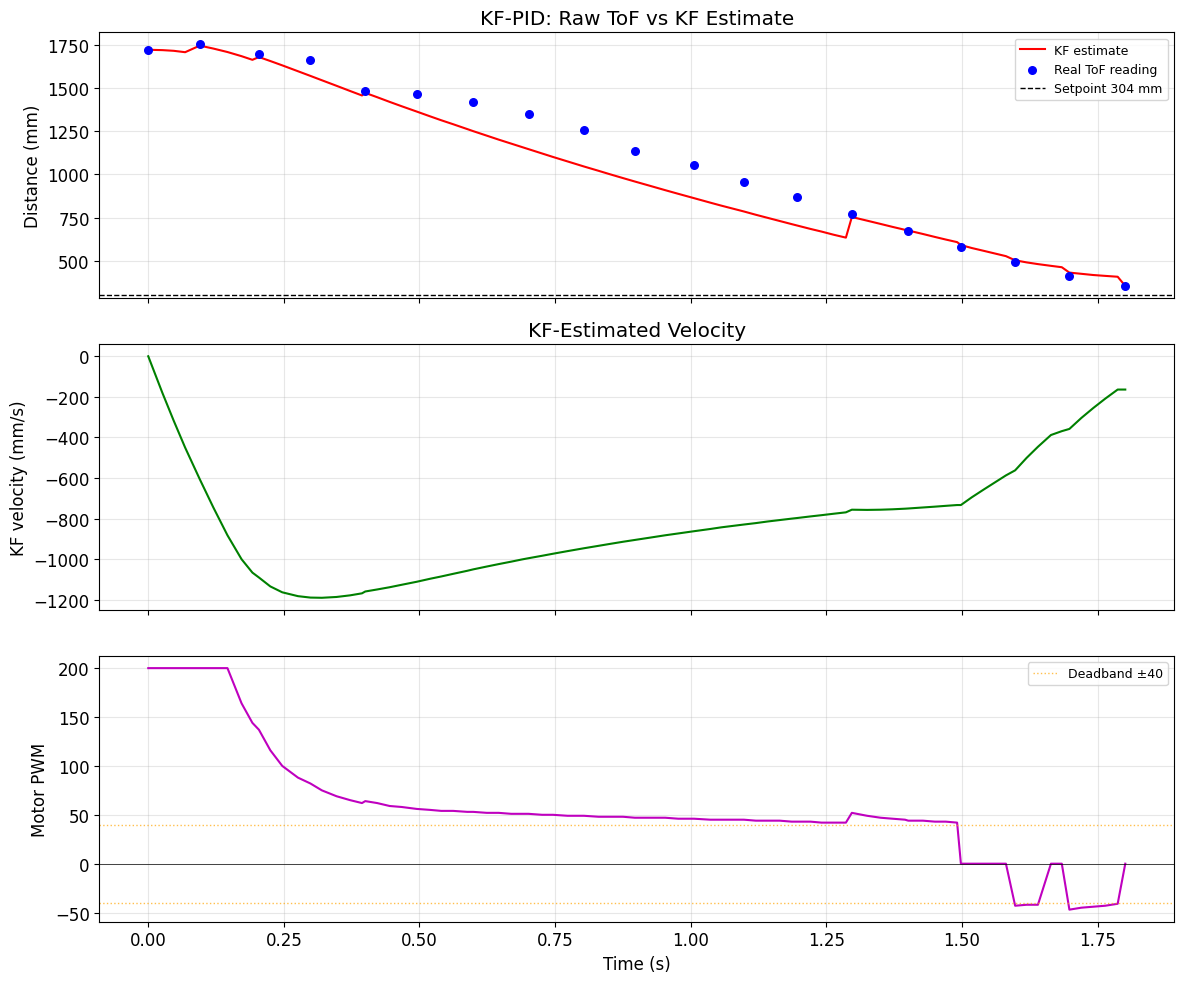

Saved -> lab7_kf_pid.png


In [48]:
# ── Plot: raw ToF vs KF estimate, velocity, motor PWM ─────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Top: distance
ax = axes[0]
ax.plot(dbg_df['time_s'], dbg_df['est_mm'],  'r-',  lw=1.5, label='KF estimate')
ax.scatter(dbg_df.loc[dbg_df['real_tof'], 'time_s'],
           dbg_df.loc[dbg_df['real_tof'], 'raw_mm'],
           color='blue', s=30, zorder=5, label='Real ToF reading')
ax.axhline(SETPOINT_MM, color='k', linestyle='--', lw=1, label=f'Setpoint {SETPOINT_MM} mm')
ax.set_ylabel('Distance (mm)')
ax.set_title('KF-PID: Raw ToF vs KF Estimate')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Middle: KF velocity estimate
ax = axes[1]
ax.plot(dbg_df['time_s'], dbg_df['vel_mmps'], 'g-', lw=1.5)
ax.set_ylabel('KF velocity (mm/s)')
ax.set_title('KF-Estimated Velocity')
ax.grid(alpha=0.3)

# Bottom: motor PWM
ax = axes[2]
ax.plot(dbg_df['time_s'], dbg_df['pwm'], 'm-', lw=1.5)
ax.axhline(0,   color='k', lw=0.5)
ax.axhline( 40, color='orange', linestyle=':', lw=1, alpha=0.7, label='Deadband ±40')
ax.axhline(-40, color='orange', linestyle=':', lw=1, alpha=0.7)
ax.set_ylabel('Motor PWM')
ax.set_xlabel('Time (s)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lab7_kf_pid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> lab7_kf_pid.png')

In [49]:
# ── Summary statistics ────────────────────────────────────────────────────────
if len(dbg_df):
    final_est = dbg_df['est_mm'].iloc[-1]
    final_raw = dbg_df.loc[dbg_df['real_tof'], 'raw_mm'].iloc[-1] if dbg_df['real_tof'].any() else float('nan')
    n_real_tof = dbg_df['real_tof'].sum()
    n_kf_only  = len(dbg_df) - n_real_tof
    print(f'Final KF estimate: {final_est:.0f} mm  (error: {final_est - SETPOINT_MM:.0f} mm)')
    print(f'Final raw ToF:     {final_raw:.0f} mm')
    print(f'Total DBG rows:    {len(dbg_df)}')
    print(f'  Real ToF updates: {n_real_tof}')
    print(f'  Prediction-only:  {n_kf_only} ({100*n_kf_only/len(dbg_df):.0f}%)')

Final KF estimate: 356 mm  (error: 52 mm)
Final raw ToF:     356 mm
Total DBG rows:    84
  Real ToF updates: 19
  Prediction-only:  65 (77%)


---
## 10. Disconnect

In [50]:
ble.disconnect()
print('Disconnected from Artemis.')

Disconnected from Artemis.
